<a href="https://colab.research.google.com/github/VictorHugoTesti/-am-t4-s1a2026/blob/main/prova_21_Victor_Testi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prova 21: IBAMA | Autuações e Multas Ambientais

**Consumo:** Base com valores monetários em formato de string com vírgulas (ex: "1.500,00").

**Alvo ($Y$):** Multa_Grave se o valor da multa ultrapassar a mediana da base.

**Desafio:** Conversão robusta de strings financeiras para float antes do StandardScaler.

Nome: Victor Hugo Malipense Testi

# Pipeline | Extração [Fase 1 - base_ibama]

## Bibliotecas Python

In [214]:
!pip -q install plotly
!pip -q install yellowbrick

In [215]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [216]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [217]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Importar Dados do Drive

In [218]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Importar DataFrame [base_ibama]

In [219]:
base_ibama = pd.read_csv('/content/drive/MyDrive/Aprendizagem de Maquina/prova - ML/volumeJulgamentoAI.csv', sep=';')

In [220]:
base_ibama

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Número AI,Nome ou Razão Social,CPF/CNPJ,UF,Município,Status Débito,Decisão Administrativa,Tipo Auto,Tipo de Infração,Enquadramento,Data Julgamento Principal,Data Julgamento Recurso,Data Auto,Valor do Auto,Moeda,Valor Pago,Data Pagamento,Última Atualização Relatório
0,0QRNTRF2 -,RONALDO DA COSTA CUNHA,792.049.372-20,AC,CRUZEIRO DO SUL,Quitado. Baixa automática,NaN,Multa,Fauna,"Lei 9605/98 - Artigo 72, Lei 9605/98 - Artigo ...",NaN,23/02/2026,26/01/2026,500,Real,"353,5",20/02/2026,19/04/2026 21:56
1,0YIWNUKS -,JUZALDO RUFINO MOTA,411.867.022-49,AC,RIO BRANCO,Quitado. Baixa automática,NaN,Multa,Flora,Decreto 6514/2008 - Artigo 57,NaN,25/09/2025,03/04/2023,"1,000",Real,707,14/04/2023,19/04/2026 21:56
2,11175 - D,PAULO COUTO CABRAL,363.359.919-34,AC,RIO BRANCO,Quitado. Baixa automática,NaN,Multa,Flora,NaN,30/09/1998,NaN,31/08/1998,"1,240",Real,305,02/12/1998,19/04/2026 21:56
3,112481 - D,OURO BRANCO MADEIRAS IMP. E EXP. LTDA.,00.525.034/0001-08,AC,CAPIXABA,Quitado. Baixa automática,NaN,Multa,Flora,NaN,22/08/2003,NaN,20/01/2003,"5,588",Real,"3,854,3",11/09/2003,19/04/2026 21:56
4,11255 - D,SINÉZIO JOSÉ FALCÃO,139.287.402-53,AC,ACRELANDIA,Parcelado pela 1ª vez,NaN,Multa,Flora,NaN,30/09/1998,NaN,04/09/1998,500,Real,"73,4",22/03/2000,19/04/2026 21:56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,WIZBMOWS -,MARIA ADÉLIA FALTZ BREDA,015.205.617-33,AC,ACRELANDIA,Quitado. Baixa automática,NaN,Multa,Flora,"Lei 9605/98 - Artigo 72, Lei 9605/98 - Artigo ...",NaN,NaN,12/08/2025,"30,000",Real,"21,000",26/08/2025,19/04/2026 21:56
2913,XFSQE06B -,VICTOR FAVORETO MOURA HYPOLITTO,469.999.878-07,AC,RIO BRANCO,Quitado. Baixa automática,NaN,Multa,Fauna,"Lei 9605/98 - Artigo 72, Decreto 6514/2008 - A...",NaN,23/09/2024,14/06/2024,500,Real,"359,7",23/09/2024,19/04/2026 21:56
2914,YA6X8PV7 -,CELIO FERREIRA FURTADO,860.048.912-15,AC,SENA MADUREIRA,Quitado. Baixa automática,NaN,Multa,Fauna,"Lei 9605/98 - Artigo 70, Decreto 6514/2008 - A...",NaN,NaN,12/09/2022,"5,000",Real,"4,045,3",15/12/2023,19/04/2026 21:56
2915,ZE5A8NQQ -,FRANCISCO SERGIO FRANCO DE SOUZA,612.722.992-87,AC,BRASILEIA,Quitado. Baixa automática,NaN,Multa,Cadastro Técnico Federal,"Lei 9605/98 - Artigo 70, Decreto 6514/2008 - A...",NaN,NaN,02/09/2023,"1,000",Real,"720,8",22/11/2023,19/04/2026 21:56


# Pipeline | Tratamento e Normalização [Fase 2 - base_ibama]

## Padronizando e Convertendo "Valor do Auto" de text para float

In [221]:
def padrao_valor(valor):
  if pd.isna(valor):
    return np.nan

  valor_str = str(valor).strip()

  if ',' not in valor_str:
    return float(valor_str)

  partes = valor_str.rsplit(',', 1)

  if len(partes[1]) == 3:
         valor_limpo = valor_str.replace(',', '')
  else:
         valor_limpo = partes[0].replace(',', '') + '.' + partes[1]

  return float(valor_limpo)

In [222]:
base_ibama['Valor do Auto'] = base_ibama['Valor do Auto'].apply(padrao_valor)

In [223]:
base_ibama['Valor do Auto'].describe()

,Valor do Auto
count,2917.000000
mean,6958.789407
std,24672.863332
min,50.000000
25%,500.000000
50%,1000.000000
75%,3000.000000
max,595500.000000


In [224]:
base_ibama['Valor do Auto'].head()

,Valor do Auto
0,500.0
1,1000.0
2,1240.0
3,5588.0
4,500.0


## Detecção de Anomalias

### Possiveis Nulidades - (Dados Nulos em Base)

In [225]:
base_ibama.isnull().sum()

,0
Número AI,0
Nome ou Razão Social,0
CPF/CNPJ,30
UF,0
Município,0
Status Débito,0
Decisão Administrativa,2659
Tipo Auto,0
Tipo de Infração,0
Enquadramento,1684


### Possiveis Valores de Multas Negativas - (Incongruencias ou Impossibilidades)

In [226]:
base_ibama.loc[base_ibama['Valor do Auto'] < 0]

,Número AI,Nome ou Razão Social,CPF/CNPJ,UF,Município,Status Débito,Decisão Administrativa,Tipo Auto,Tipo de Infração,Enquadramento,Data Julgamento Principal,Data Julgamento Recurso,Data Auto,Valor do Auto,Moeda,Valor Pago,Data Pagamento,Última Atualização Relatório


## Tratamento e Padronização de Anomalias

### Substituindo Campos Vazios (NaN) da Coluna "Enquadramento" por valor "Não Informado"

In [227]:
base_ibama['Enquadramento'] = base_ibama['Enquadramento'].fillna('Nao Informado')

In [228]:
base_ibama.isnull().sum()

,0
Número AI,0
Nome ou Razão Social,0
CPF/CNPJ,30
UF,0
Município,0
Status Débito,0
Decisão Administrativa,2659
Tipo Auto,0
Tipo de Infração,0
Enquadramento,0


### Substituindo Campos Vazios (NaN) da Coluna "CPF/CNPJ" por valor "Não Informado"

In [229]:
base_ibama['CPF/CNPJ'] = base_ibama['CPF/CNPJ'].fillna('Nao Informado')

In [230]:
base_ibama.isnull().sum()

,0
Número AI,0
Nome ou Razão Social,0
CPF/CNPJ,0
UF,0
Município,0
Status Débito,0
Decisão Administrativa,2659
Tipo Auto,0
Tipo de Infração,0
Enquadramento,0


### Substituindo Campos Vazios (NaN) da Coluna "Decisão Administrativa" por valor "Não Informado"

In [231]:
base_ibama['Decisão Administrativa'] = base_ibama['Decisão Administrativa'].fillna('Não Informado')

In [232]:
base_ibama.isnull().sum()

,0
Número AI,0
Nome ou Razão Social,0
CPF/CNPJ,0
UF,0
Município,0
Status Débito,0
Decisão Administrativa,0
Tipo Auto,0
Tipo de Infração,0
Enquadramento,0


### Substituindo Campos Vazios (NaN) da Coluna "Data Julgamento Principal" por valor "Não Informado"

In [233]:
base_ibama['Data Julgamento Principal'] = base_ibama['Data Julgamento Principal'].fillna('Não Informado')

In [234]:
base_ibama.isnull().sum()

,0
Número AI,0
Nome ou Razão Social,0
CPF/CNPJ,0
UF,0
Município,0
Status Débito,0
Decisão Administrativa,0
Tipo Auto,0
Tipo de Infração,0
Enquadramento,0


### Substituindo Campos Vazios (NaN) da Coluna "Data Julgamento Recurso" por valor "Não Informado"

In [235]:
base_ibama['Data Julgamento Recurso'] = base_ibama['Data Julgamento Recurso'].fillna('Não Informado')

In [236]:
base_ibama.isnull().sum()

,0
Número AI,0
Nome ou Razão Social,0
CPF/CNPJ,0
UF,0
Município,0
Status Débito,0
Decisão Administrativa,0
Tipo Auto,0
Tipo de Infração,0
Enquadramento,0


# Pipeline | Visualização [Fase 3 - base_ibama]

In [237]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

### [Gráfico] Distribuição dos Valores das Multas

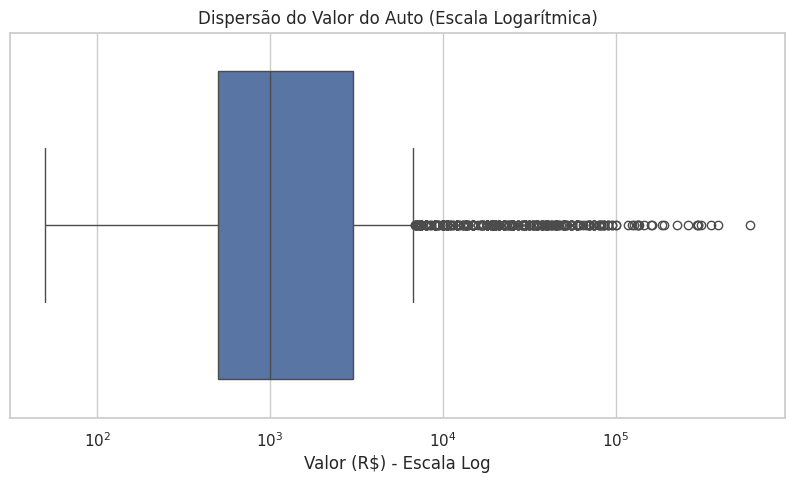

In [238]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=base_ibama['Valor do Auto'])
plt.xscale('log')
plt.title('Dispersão do Valor do Auto (Escala Logarítmica)')
plt.xlabel('Valor (R$) - Escala Log')
plt.show()

### [Gráfico] Top 10 Estados (UF) com maior Volume de Atuações

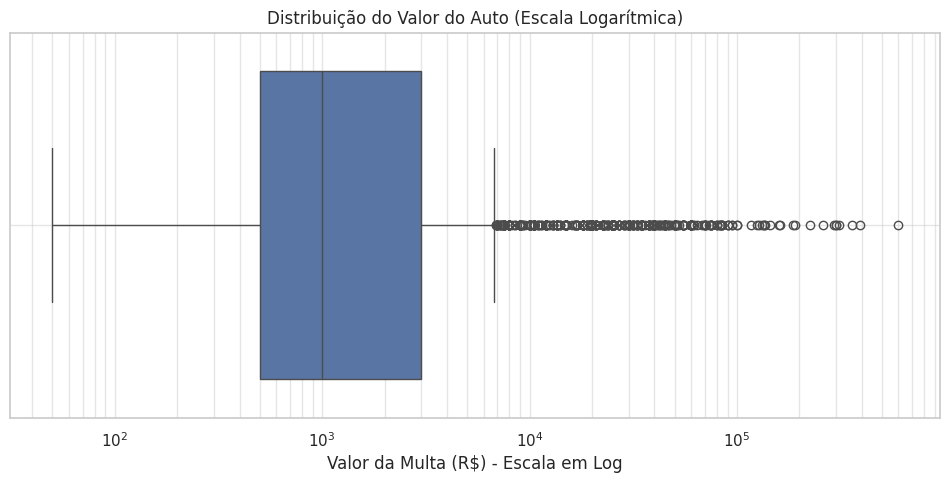

In [239]:
plt.figure(figsize=(12, 5))
sns.boxplot(x=base_ibama[base_ibama['Valor do Auto'] > 0]['Valor do Auto'])
plt.xscale('log')
plt.title('Distribuição do Valor do Auto (Escala Logarítmica)')
plt.xlabel('Valor da Multa (R$) - Escala em Log')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

### [Gráfico] Distribuição por Tipo de Infração

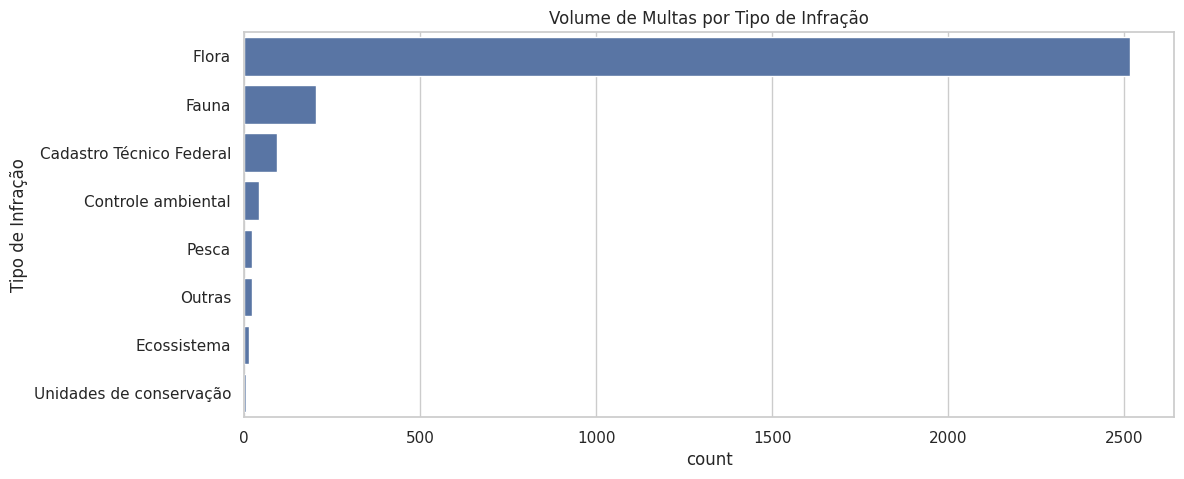

In [240]:
plt.figure(figsize=(12, 5))
sns.countplot(data=base_ibama, y='Tipo de Infração', order=base_ibama['Tipo de Infração'].value_counts().index)
plt.title('Volume de Multas por Tipo de Infração')
plt.show()

# Pipeline | Laborização [Fase 4 - base_ibama]

## Cálculo da Mediana e Desvio Padrão

In [241]:
mediana = base_ibama['Valor do Auto'].median()
mediana

1000.0

In [242]:
desvio = base_ibama['Valor do Auto'].std()
desvio

24672.86333236209

## Alvos de Aprendizagem

### Tipo de Multa [Target - Multa_Grave]

In [243]:
base_ibama['Multa_Grave'] = np.where(base_ibama['Valor do Auto'] > mediana, 1, 0)

In [244]:
base_ibama['Multa_Grave']

,Multa_Grave
0,0
1,0
2,1
3,1
4,0
...,...
2912,1
2913,0
2914,1
2915,0


#### [Gráfico] Distribuição das Multas Graves VS Multar Normais

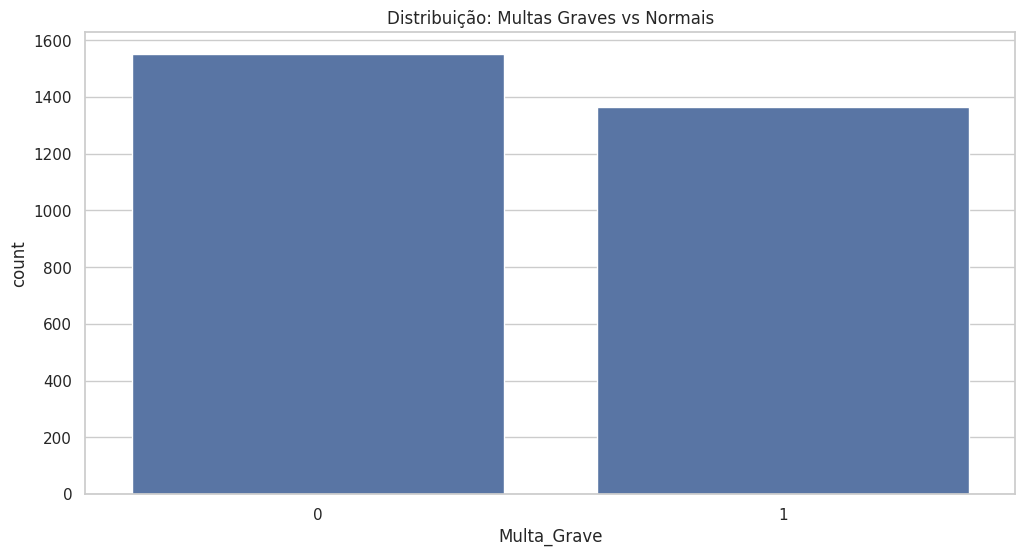

In [245]:
sns.countplot(x='Multa_Grave', data=base_ibama)
plt.title('Distribuição: Multas Graves vs Normais')
plt.show()

### Filtrando Municípios (Top 50) [Target - Município_Limpo]

In [246]:
top_municipios = base_ibama['Município'].value_counts().nlargest(50).index

In [247]:
base_ibama['Município_Limpo'] = base_ibama['Município'].where(
    base_ibama['Município'].isin(top_municipios), 'Outros')

### Separando entre Empresa e Cidadão [Target - Is_Company]

In [248]:
base_ibama['Is_Company'] = base_ibama['CPF/CNPJ'].str.contains('/', na=False).astype(int)

In [249]:
base_ibama['Is_Company'].value_counts()

,count
Is_Company,
0,2430
1,487


### Separando entre Estações do Ano [Target - Estacao_Ano | Mes_Auto]

In [250]:
base_ibama['Data Auto'] = pd.to_datetime(base_ibama['Data Auto'], format='%d/%m/%Y', errors='coerce')
base_ibama['Mes_Auto'] = base_ibama['Data Auto'].dt.month

In [251]:
def estacoes(mes):
    if pd.isna(mes):
        return 'Nao Informado'

    mes = int(mes)
    if mes in [12, 1, 2]:
        return 'Verao'
    elif mes in [3, 4, 5]:
        return 'Outono'
    elif mes in [6, 7, 8]:
        return 'Inverno'
    elif mes in [9, 10, 11]:
        return 'Primavera'

In [252]:
base_ibama['Estacao_Ano'] = base_ibama['Mes_Auto'].apply(estacoes)

In [253]:
base_ibama['Estacao_Ano'].value_counts()

,count
Estacao_Ano,
Primavera,1271
Inverno,855
Verao,409
Outono,382


In [254]:
base_ibama[['Data Auto', 'Mes_Auto', 'Estacao_Ano']].head()

,Data Auto,Mes_Auto,Estacao_Ano
0,2026-01-26,1,Verao
1,2023-04-03,4,Outono
2,1998-08-31,8,Inverno
3,2003-01-20,1,Verao
4,1998-09-04,9,Primavera


#### [Gráfico] Relação Sazonal: Estação do Ano vs. Valor Médio da Multa

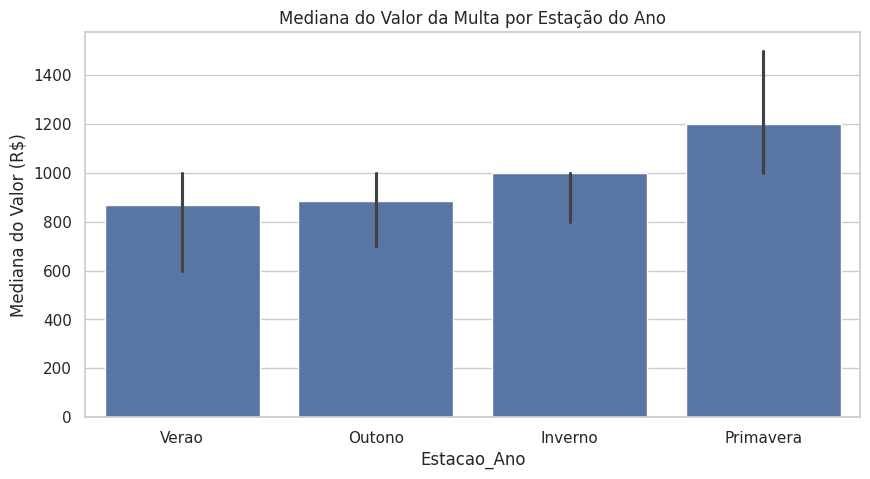

In [255]:
plt.figure(figsize=(10, 5))
sns.barplot(data=base_ibama, x='Estacao_Ano', y='Valor do Auto', estimator=np.median)
plt.title('Mediana do Valor da Multa por Estação do Ano')
plt.ylabel('Mediana do Valor (R$)')
plt.show()

## Eixos de Aprendizagem

In [256]:
base_ibama.columns

Index(['Número AI', 'Nome ou Razão Social', 'CPF/CNPJ', 'UF', 'Município',
       'Status Débito', 'Decisão Administrativa', 'Tipo Auto',
       'Tipo de Infração', 'Enquadramento', 'Data Julgamento Principal',
       'Data Julgamento Recurso', 'Data Auto', 'Valor do Auto', 'Moeda',
       'Valor Pago', 'Data Pagamento', 'Última Atualização Relatório',
       'Multa_Grave', 'Município_Limpo', 'Is_Company', 'Mes_Auto',
       'Estacao_Ano'],
      dtype='object')

In [257]:
Y_ibama = base_ibama['Multa_Grave'].values
Y_ibama

array([0, 0, 1, ..., 1, 0, 1])

In [258]:
X_ibama = base_ibama[['UF', 'Tipo de Infração', 'Município_Limpo', 'Tipo Auto', 'Is_Company', 'Estacao_Ano']].values
X_ibama

array([['AC', 'Fauna', 'CRUZEIRO DO SUL', 'Multa', 0, 'Verao'],
       ['AC', 'Flora', 'RIO BRANCO', 'Multa', 0, 'Outono'],
       ['AC', 'Flora', 'RIO BRANCO', 'Multa', 0, 'Inverno'],
       ...,
       ['AC', 'Fauna', 'SENA MADUREIRA', 'Multa', 0, 'Primavera'],
       ['AC', 'Cadastro Técnico Federal', 'BRASILEIA', 'Multa', 0,
        'Primavera'],
       ['AC', 'Controle ambiental', 'RIO BRANCO', 'Multa', 1, 'Inverno']],
      dtype=object)

## MultiLabelBinarizer

In [259]:
enquadramento_listas = base_ibama['Enquadramento'].str.split(',').apply(lambda x: [i.strip() for i in x])

In [260]:
mlb = MultiLabelBinarizer()
enquadramento_encoded = mlb.fit_transform(enquadramento_listas)

In [261]:
print(f"Número de colunas criadas para Enquadramento: {enquadramento_encoded.shape[1]}")
print("Exemplo de classe:", mlb.classes_[:5])

Número de colunas criadas para Enquadramento: 226
Exemplo de classe: ['47' 'Const. Federal - Artigo 225' 'Constituição Federal - Artigo 1°'
 'Constituição Federal - Artigo 225' 'Constituição Federal - Artigo 3°']


## LabelEncoder

In [262]:
label_encoder_uf = LabelEncoder()
label_encoder_tipo_infracao = LabelEncoder()
label_encoder_municipio_limpo = LabelEncoder()
label_encoder_tipo_auto = LabelEncoder()
label_encoder_is_company = LabelEncoder()
label_encoder_estacao_ano = LabelEncoder()

In [263]:
X_ibama[:, 0] = label_encoder_uf.fit_transform(X_ibama[:, 0])
X_ibama[:, 1] = label_encoder_tipo_infracao.fit_transform(X_ibama[:, 1])
X_ibama[:, 2] = label_encoder_municipio_limpo.fit_transform(X_ibama[:, 2])
X_ibama[:, 3] = label_encoder_tipo_auto.fit_transform(X_ibama[:, 3])
X_ibama[:, 4] = label_encoder_is_company.fit_transform(X_ibama[:, 4])
X_ibama[:, 5] = label_encoder_estacao_ano.fit_transform(X_ibama[:, 5])

## OneHotEncoder

In [264]:
onehot_ibama = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(), [0, 1, 2, 3, 4])
], remainder='passthrough')

In [265]:
X_ibama = onehot_ibama.fit_transform(X_ibama).toarray()

## StandardScaler

In [266]:
X_ibama = np.hstack((X_ibama, enquadramento_encoded))

### Divisão da Base para Treino e Teste [base_ibama]

In [267]:
X_treinamento, X_teste, Y_treinamento, Y_teste = train_test_split(
    X_ibama, Y_ibama, test_size=0.15, random_state=42, stratify=Y_ibama)

In [268]:
scaler = StandardScaler()
#X_ibama =  scaler.fit_transform(X_ibama)
X_treinamento = scaler.fit_transform(X_treinamento)
X_teste = scaler.transform(X_teste)

In [269]:
X_treinamento.shape, X_teste.shape

((2479, 261), (438, 261))

In [270]:
Y_treinamento.shape, Y_teste.shape

((2479,), (438,))

### Exportação do Arquivo Pickle (Digest)

In [271]:
import pickle

In [272]:
with open ('/content/drive/MyDrive/Aprendizagem de Maquina/ibama.pkl', mode='wb') as f:
  pickle.dump([X_treinamento, Y_treinamento, X_teste, Y_teste], f)

# Pipeline | Ingestão Bayesiana [Fase 5 - base_ibama]

## Treinamento - GaussianNB()

In [280]:
modelo_nb = GaussianNB(var_smoothing=0.1)
modelo_nb.fit(X_treinamento, Y_treinamento)

GaussianNB(var_smoothing=0.1)

### Avaliação - Acuracia e Matriz de Confusão [GaussianNB]

In [281]:
previsoes = modelo_nb.predict(X_teste)

In [282]:
print("Acurácia:", accuracy_score(Y_teste, previsoes))
print("\nMatriz de Confusão:\n", confusion_matrix(Y_teste, previsoes))
print("\nRelatório Final (Limiar 0.30):\n", classification_report(Y_teste, previsoes))

Acurácia: 0.6963470319634704

Matriz de Confusão:
 [[222  11]
 [122  83]]

Relatório Final (Limiar 0.30):
               precision    recall  f1-score   support

           0       0.65      0.95      0.77       233
           1       0.88      0.40      0.56       205

    accuracy                           0.70       438
   macro avg       0.76      0.68      0.66       438
weighted avg       0.76      0.70      0.67       438



## Treinamento - BernoulliNB()

In [283]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [284]:
modelo_nb = BernoulliNB(alpha=0.1)
modelo_nb.fit(X_treinamento, Y_treinamento)

BernoulliNB(alpha=0.1)

### Avaliação - Acuracia e Matriz de Confusão [BernoulliNB]

In [285]:
# 1. Extrair as probabilidades em vez da predição final cravada
probabilidades = modelo_nb.predict_proba(X_teste)[:, 1] # Pega a probabilidade da classe 1 (Multa Grave)

# 2. Definir o novo Limiar (Threshold) mais sensível para crimes ambientais
limiar_etico = 0.30

# 3. Gerar as novas previsões com base no novo limiar
previsoes_ajustadas = (probabilidades >= limiar_etico).astype(int)

In [286]:
print("Acurácia:", accuracy_score(Y_teste, previsoes_ajustadas))
print("\nMatriz de Confusão:\n", confusion_matrix(Y_teste, previsoes_ajustadas))
print("\nRelatório Final (Limiar 0.30):\n", classification_report(Y_teste, previsoes_ajustadas))

Acurácia: 0.6917808219178082

Matriz de Confusão:
 [[188  45]
 [ 90 115]]

Relatório Final (Limiar 0.30):
               precision    recall  f1-score   support

           0       0.68      0.81      0.74       233
           1       0.72      0.56      0.63       205

    accuracy                           0.69       438
   macro avg       0.70      0.68      0.68       438
weighted avg       0.70      0.69      0.69       438

